In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datasets
from privacy_estimates.experiments.aml import JobList, DatastoreURI, Job
from sklearn.metrics import roc_curve, auc
from tempfile import TemporaryDirectory
from datasets import load_from_disk
from latex import Project
from typing import Dict

In [2]:
jobs = JobList.from_urls([
    # synthetic
    "https://ml.azure.com/experiments/id/cbd45cd3-4fd8-4922-b82a-124527cc98ee/runs/yellow_ring_lx2h1d9qzk?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/PPML/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47",
    "https://ml.azure.com/experiments/id/cbd45cd3-4fd8-4922-b82a-124527cc98ee/runs/serene_garden_6616pjjqqg?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/PPML/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47",
    "https://ml.azure.com/experiments/id/cbd45cd3-4fd8-4922-b82a-124527cc98ee/runs/frosty_chaconia_753kyps8my?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/PPML/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47",
    "https://ml.azure.com/experiments/id/cbd45cd3-4fd8-4922-b82a-124527cc98ee/runs/cool_picture_lsyzr3zmkq?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/PPML/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47",
    # model
    "https://ml.azure.com/experiments/id/cbd45cd3-4fd8-4922-b82a-124527cc98ee/runs/upbeat_calypso_6tl7xynv7x?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/PPML/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47",
    "https://ml.azure.com/experiments/id/cbd45cd3-4fd8-4922-b82a-124527cc98ee/runs/epic_dolphin_1vlnxww2nf?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/PPML/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47",

])

In [13]:
data = pd.DataFrame({
    "type": ["synthetic", "synthetic", "synthetic", "synthetic", "model", "model"],
    "n_rep": [2, 4, 8, 16, 1, 2]
})

In [14]:
def load_from_uri(uri: DatastoreURI):
    with TemporaryDirectory() as tmpdir:
        uri.download_content(tmpdir)
        return load_from_disk(tmpdir)

In [15]:
def compute_metrics(job):
    estimate_privacy = job.get_node("estimate_privacy")
    scores = load_from_uri(estimate_privacy.inputs["scores"])
    challenge_bits = load_from_uri(estimate_privacy.inputs["challenge_bits"])

    fpr, tpr, _ = roc_curve(challenge_bits["challenge_bit"], scores["score"])
    metrics = {"FPR": fpr, "TPR": tpr}
    metrics["AuC"] = auc(fpr, tpr)
    for target_fpr in [0.01, 0.05, 0.1]:
        metrics[f"TPR@FPR={target_fpr}"] = np.interp(target_fpr, fpr, tpr)
        
    return metrics

In [16]:
data = pd.concat([data, pd.DataFrame([compute_metrics(job) for job in jobs])], axis=1)

In [17]:
data

,type,n_rep,FPR,TPR,AuC,TPR@FPR=0.01,TPR@FPR=0.05,TPR@FPR=0.1
0,synthetic,2,"[0.0, 0.002028397565922921, 0.0101419878296146...","[0.0, 0.0, 0.0, 0.0019723865877712033, 0.00197...",0.565051,0.000000,0.086785,0.149901
1,synthetic,4,"[0.0, 0.0, 0.0, 0.004056795131845842, 0.004056...","[0.0, 0.0019723865877712033, 0.021696252465483...",0.520530,0.027613,0.045365,0.082840
2,synthetic,8,"[0.0, 0.0, 0.0, 0.002028397565922921, 0.002028...","[0.0, 0.0019723865877712033, 0.009861932938856...",0.582874,0.029586,0.074951,0.132150
3,synthetic,16,"[0.0, 0.0, 0.0, 0.002028397565922921, 0.002028...","[0.0, 0.0019723865877712033, 0.003944773175542...",0.708303,0.072978,0.134122,0.293886
4,model,1,"[0.0, 0.0, 0.0, 0.002028397565922921, 0.002028...","[0.0, 0.0019723865877712033, 0.013806706114398...",0.594937,0.025641,0.153846,0.246548
5,model,2,"[0.0, 0.0, 0.0, 0.002028397565922921, 0.002028...","[0.0, 0.0019723865877712033, 0.043392504930966...",0.716540,0.157791,0.268245,0.351085


(0.0, 1.0)

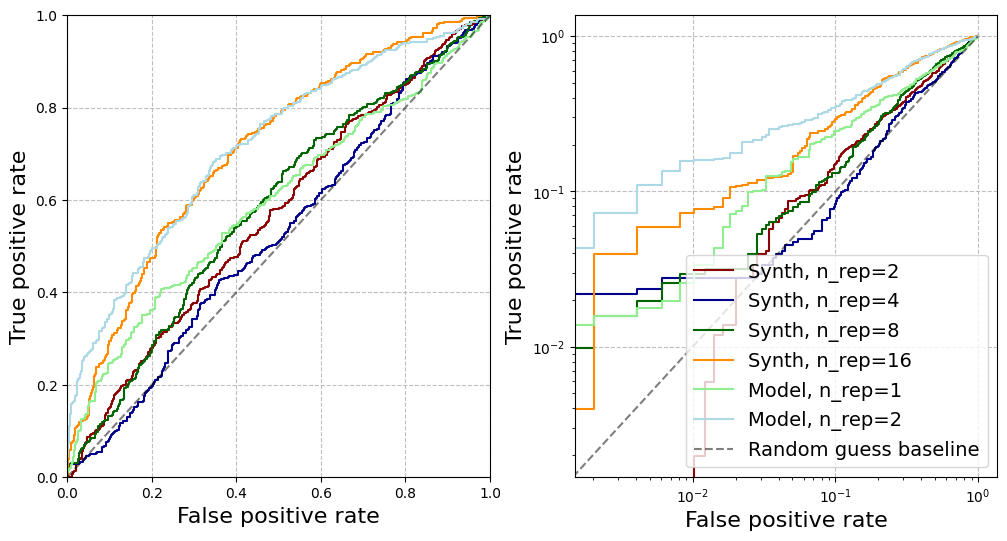

In [21]:
perp = 31
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_options = {
    ("synthetic", 2): {"color": "darkred", "label": "Synth, n_rep=2"},
    ("synthetic", 4): {"color": "darkblue", "label": "Synth, n_rep=4"},
    ("synthetic", 8): {"color": "darkgreen", "label": "Synth, n_rep=8"},
    ("synthetic", 16): {"color": "darkorange", "label": "Synth, n_rep=16"},
    ("model", 1): {"color": "lightgreen", "label": "Model, n_rep=1"},
    ("model", 2): {"color": "lightblue", "label": "Model, n_rep=2"},
}

for type, n_rep in plot_options:
    data_i = data[(data["n_rep"] == n_rep) & (data["type"] == type)]
    fpr = data_i["FPR"].values[0]
    tpr = data_i["TPR"].values[0]
    ax[0].plot(fpr, tpr, **plot_options[(type, n_rep)])
    ax[1].plot(fpr, tpr, **plot_options[(type, n_rep)])


ax[0].plot([0, 1], [0, 1], "--", color="black", alpha=0.5, label="Random guess baseline")
ax[1].plot([0, 1], [0, 1], "--", color="black", alpha=0.5, label="Random guess baseline")
ax[0].set_xlabel("False positive rate", fontsize=16)
ax[0].set_ylabel("True positive rate", fontsize=16)
ax[1].set_xlabel("False positive rate", fontsize=16)
ax[1].set_ylabel("True positive rate", fontsize=16)
ax[1].legend(loc="lower right", fontsize=14)
ax[0].grid(True, which="major", ls="--", alpha=0.8)
ax[1].grid(True, which="major", ls="--", alpha=0.8)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)

In [ ]:
overleaf = Project(url="https://git@git.overleaf.com/667bde737a03ee4008a9359f")
for (type, n_rep), options in plot_options.items():
    df_i = data[(data["n_rep"] == n_rep) & (data["type"] == type)]
    roc = pd.DataFrame({"fpr": df_i["FPR"].values[0], "tpr": df_i["TPR"].values[0]})
    overleaf.push_dataframe(roc, f"data/n_rep/sst2/roc/{type}_{n_rep}.tsv")